In [19]:
import AA500
import matplotlib.pyplot as plt
import pandas as pd

# 5-21-25 Nutrient Analyzer Run QAQC

In [2]:
result_dir = '/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/Reynolds Nitrate Monitoring/Nutrient Analyzer Data/20250331 Run/'

result_05212025 = AA500.AA500_Result(result_dir + 'RCEW_NOx-PO4-NH4_Apr2025_2_2.csv', result_dir+'samplelist_20250331_2.xlsx')

                                   Site Number  Sample Number  \
Site Name     Sample Datetime                                   
DI Blank      NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                        166.0            NaN   
Dobson        2025-02-05 01:00:00        135.0            1.1   
...                                        ...            ...   
RME           2025-03-25 10:19:00        166.0            8.1   
              2025-03-25 10:19:00        166.0            8.2   
Reagent Blank NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                          NaN            NaN   

                                  Sample Collected  \
Site Name     Sample Datetime                        
DI Blank      NaT                             

/Users/beneck/Repos/rcew-nitrate/AA500.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(path, header=14, parse_dates=['Date Time Stamp']).rename(columns = self._result_mapping)


## Drift and Baseline

In [3]:
result_05212025.result_df

Site Number  Sample Number  \
Site Name     Sample Datetime                                   
DI Blank      NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                        166.0            NaN   
Dobson        2025-02-05 01:00:00        135.0            1.1   
...                                        ...            ...   
RME           2025-03-25 10:19:00        166.0            8.1   
              2025-03-25 10:19:00        166.0            8.2   
Reagent Blank NaT                          NaN            NaN   
              NaT                          NaN            NaN   
              NaT                          NaN            NaN   

                                  Sample Collected  \
Site Name     Sample Datetime                        
DI Blank      NaT                              NaT   
              NaT                              NaT   
              NaT                              NaT   
              NaT                              NaT   
Dobson        2025-02-05 01:00:00       2025-02-05   
...                                            ...   
RME           2025-03-25 10:19:00       2025-03-25   
              2025-03-25 10:19:00       2025-03-25   
Reagent Blank NaT                              NaT   
              NaT                              NaT   
              NaT                              NaT   

                                   Julian Day Sample Collected  \
Site Name     Sample Datetime                                    
DI Blank      NaT                                          NaN   
              NaT                                          NaN   
              NaT                                          NaN   
              NaT                                          NaN   
Dobson        2025-02-05 01:00:00                         36.0   
...                                                        ...   
RME           2025-03-25 10:19:00                         84.0   
              2025-03-25 10:19:00                         84.0   
Reagent Blank NaT                                          NaN   
              NaT                                          NaN   
              NaT                                          NaN   

                                   Year Sample Collected  \
Site Name     Sample Datetime                              
DI Blank      NaT                                    NaN   
              NaT                                    NaN   
              NaT                                    NaN   
              NaT                                    NaN   
Dobson        2025-02-05 01:00:00                 2025.0   
...                                                  ...   
RME           2025-03-25 10:19:00                 2025.0   
              2025-03-25 10:19:00                 2025.0   
Reagent Blank NaT                                    NaN   
              NaT                                    NaN   
              NaT                                    NaN   

                                  Time Sample Collected  \
Site Name     Sample Datetime                             
DI Blank      NaT                                   NaN   
              NaT                                   NaN   
              NaT                                   NaN   
              NaT                                   NaN   
Dobson        2025-02-05 01:00:00              01:00:00   
...                                                 ...   
RME           2025-03-25 10:19:00              10:19:00   
              2025-03-25 10:19:00              10:19:00   
Reagent Blank NaT                                   NaN   
              NaT                                   NaN   
              NaT                                   NaN   

                                   Autosampler Tray Collected  \
Site Name    

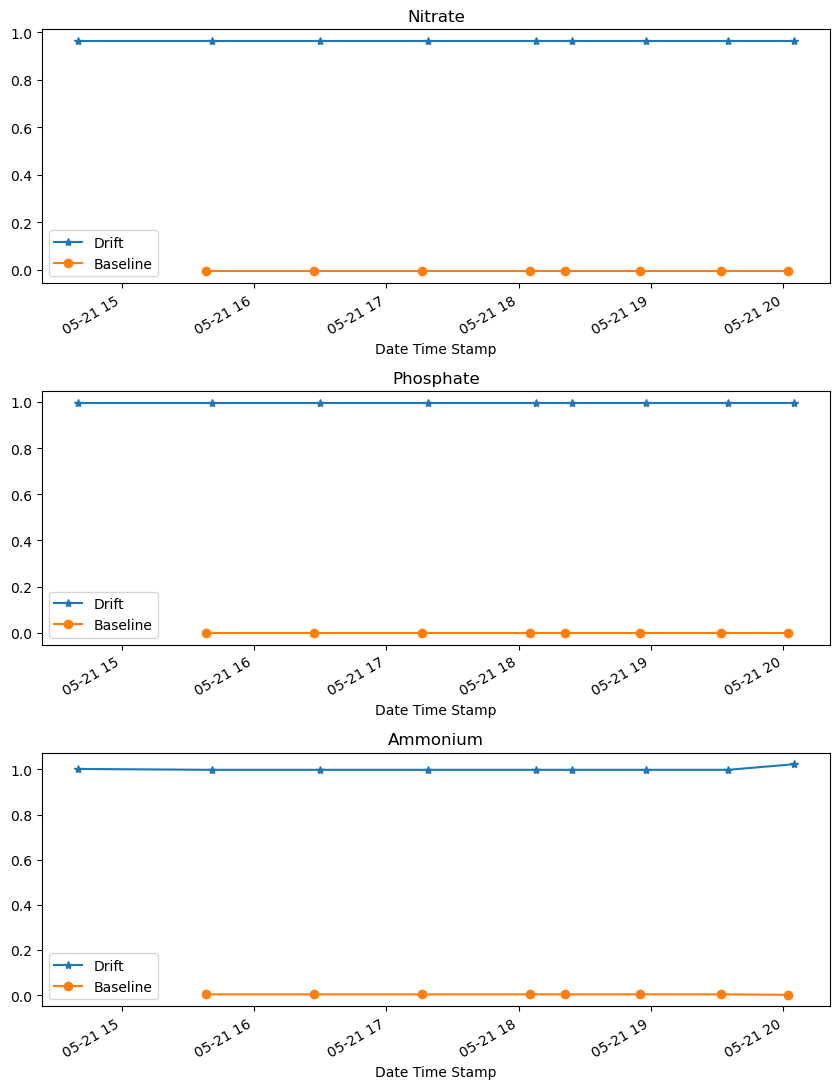

In [4]:
fig, ax = plt.subplots(figsize=(8.5,11), nrows = 3)

result_05212025.plot_QA('Nitrate', ax=ax[0], title='Nitrate')
result_05212025.plot_QA('Phosphate', ax=ax[1], title='Phosphate')
result_05212025.plot_QA('Ammonium', ax=ax[2], title='Ammonium')
fig.tight_layout()

- drift and baseline all look good except last ammonium drift

## Blank Check

In [5]:
result_05212025.result_df.loc['DI Blank'][['Nitrate mean', 'Phosphate mean', 'Ammonium mean']].describe()

,Nitrate mean,Phosphate mean,Ammonium mean
count,4.000000,4.000000,4.000000
mean,0.060750,0.041167,0.012583
std,0.124861,0.080781,0.001988
min,-0.004000,0.000000,0.009667
25%,-0.003250,0.000500,0.012167
50%,-0.000500,0.001167,0.013333
75%,0.063500,0.041833,0.013750
max,0.248000,0.162333,0.014000


- interesting, one DI Blank was pretty bad. contamination or off by one sample?

In [6]:
result_05212025.result_df.loc['DI Blank'][['Nitrate mean', 'Phosphate mean', 'Ammonium mean']]

,Nitrate mean,Phosphate mean,Ammonium mean
Sample Datetime,,,
NaT,0.002,0.001667,0.013667
NaT,-0.003,0.000667,0.013000
NaT,0.248,0.162333,0.014000
NaT,-0.004,0.000000,0.009667


In [7]:
result_05212025.result_df.loc['Reagent Blank'][['Nitrate mean', 'Phosphate mean', 'Ammonium mean']].describe()

,Nitrate mean,Phosphate mean,Ammonium mean
count,3.000000,3.000000,3.000000
mean,-0.002556,0.002778,0.015444
std,0.001388,0.001388,0.003339
min,-0.003667,0.001667,0.012000
25%,-0.003333,0.002000,0.013833
50%,-0.003000,0.002333,0.015667
75%,-0.002000,0.003333,0.017167
max,-0.001000,0.004333,0.018667


- reagent blanks look good for nitrate and phosphate. 
- ammonium mean is high, but is pretty similar to DI blanks, so this seems like a problem with ammonium standards or milliQ is contaminated

## AA500 In-Sample Variation

In [8]:
result_05212025.result_df.loc['RME'][['Nitrate std', 'Phosphate std', 'Ammonium std']].describe()

,Nitrate std,Phosphate std,Ammonium std
count,27.000000,2.700000e+01,27.000000
mean,0.001761,2.991482e-03,0.000787
std,0.003305,3.575440e-03,0.001458
min,0.000000,4.249187e-18,0.000000
25%,0.000577,1.077350e-03,0.000000
50%,0.000577,2.000000e-03,0.000577
75%,0.001630,3.014248e-03,0.001077
max,0.017349,1.628906e-02,0.007506


nitrate:
- mean of 1.7 ug/L great- SEAl reported 3-5 ug/L for this range
- most samples ok, but a few bad ones - throw those out
- qa threshold of 5 ug/l

phosphate:
- also great- mean of 3 ug/L in range of 4 ug/L in SEAL datasheet
- also a bad one or two
- qa threshold of 4 ug/l

ammonium:
- way better than seal spec! 75% less than 1 ug/L, seal spec is 2 ug/L
- one bad one with a max of 7 ug/L
- qa threshold of 2 ug/l


In [9]:
result_05212025.result_df.loc['RME']

,Site Number,Sample Number,Sample Collected,Julian Day Sample Collected,Year Sample Collected,Time Sample Collected,Autosampler Tray Collected,Julian Day Autosampler Tray Collected,Sample Type,Collected By,...,Notes,Nitrate mean,Nitrate std,Phosphate mean,Phosphate std,Ammonium mean,Ammonium std,Nitrate QA,Phosphate QA,Ammonium QA
Sample Datetime,,,,,,,,,,,,,,,,,,,,,
2025-02-14 11:00:00,166.0,1.2,2025-02-14,45.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.067667,0.000577,0.023000,1.732051e-03,0.012000,2.124594e-18,,,
2025-02-14 11:00:00,166.0,1.1,2025-02-14,45.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.069667,0.000577,0.025000,4.358899e-03,0.012000,1.000000e-03,,ISV,
2025-02-15 03:30:00,166.0,7.1,2025-02-15,46.0,2025.0,03:30:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.293667,0.001155,0.042333,2.516611e-03,0.018000,1.000000e-03,,,
2025-02-16 11:00:00,166.0,2.2,2025-02-16,47.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.046667,0.000577,0.021333,2.081666e-03,0.011000,1.000000e-03,,,
2025-02-16 11:00:00,166.0,2.1,2025-02-16,47.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.050667,0.001155,0.024000,4.249187e-18,0.013333,5.773503e-04,,,
2025-02-18 11:00:00,166.0,3.1,2025-02-18,49.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.040333,0.000577,0.022667,5.773503e-04,0.034333,5.773503e-04,,,
2025-02-20 11:00:00,166.0,4.2,2025-02-20,51.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.052667,0.004933,0.020333,5.773503e-04,0.011000,2.124594e-18,,,
2025-02-20 11:00:00,166.0,4.1,2025-02-20,51.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.063667,0.000577,0.042333,3.511885e-03,0.019000,0.000000e+00,,,
2025-02-22 11:00:00,166.0,5.1,2025-02-22,53.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.218333,0.001528,0.031667,2.309401e-03,0.013000,0.000000e+00,,,


In [11]:
result_05212025.result_df.loc['Dobson']

,Site Number,Sample Number,Sample Collected,Julian Day Sample Collected,Year Sample Collected,Time Sample Collected,Autosampler Tray Collected,Julian Day Autosampler Tray Collected,Sample Type,Collected By,...,Notes,Nitrate mean,Nitrate std,Phosphate mean,Phosphate std,Ammonium mean,Ammonium std,Nitrate QA,Phosphate QA,Ammonium QA
Sample Datetime,,,,,,,,,,,,,,,,,,,,,
2025-02-05 01:00:00,135.0,1.1,2025-02-05,36.0,2025.0,01:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.577667,5.773503e-04,0.060000,0.000000,0.031000,1.732051e-03,,,
2025-02-05 01:00:00,135.0,1.2,2025-02-05,36.0,2025.0,01:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.450333,2.309401e-03,0.050333,0.002887,0.028000,0.000000e+00,,,
2025-02-05 01:30:00,135.0,2.1,2025-02-05,36.0,2025.0,01:30:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.430333,1.527525e-03,0.092000,0.006928,0.023333,1.527525e-03,,ISV,
2025-02-05 02:00:00,135.0,3.2,2025-02-05,36.0,2025.0,02:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.599000,2.000000e-03,0.104333,0.002082,0.017000,0.000000e+00,,,
2025-02-05 02:00:00,135.0,3.1,2025-02-05,36.0,2025.0,02:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.611000,0.000000e+00,0.108333,0.002082,0.016000,0.000000e+00,,,
2025-02-05 02:30:00,135.0,4.1,2025-02-05,36.0,2025.0,02:30:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.321000,1.000000e-03,0.065667,0.002309,0.016667,2.886751e-03,,,ISV
2025-02-05 02:30:00,135.0,4.2,2025-02-05,36.0,2025.0,02:30:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.419000,3.464102e-03,0.094333,0.001155,0.022000,4.249187e-18,,,
2025-02-05 03:00:00,135.0,5.1,2025-02-05,36.0,2025.0,03:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.408333,5.773503e-04,0.070667,0.000577,0.017333,5.773503e-04,,,
2025-02-05 03:00:00,135.0,5.2,2025-02-05,36.0,2025.0,03:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.336333,1.154701e-03,0.078667,0.005508,0.033667,5.773503e-04,,ISV,


- nice. for nitrate QA flag, RME has only one, Dobson has zero. 
- most flags for phosphate, a couple for ammonium. but no wholesale bad data

## Between Bottle Variation

<Axes: title={'center': 'RME Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

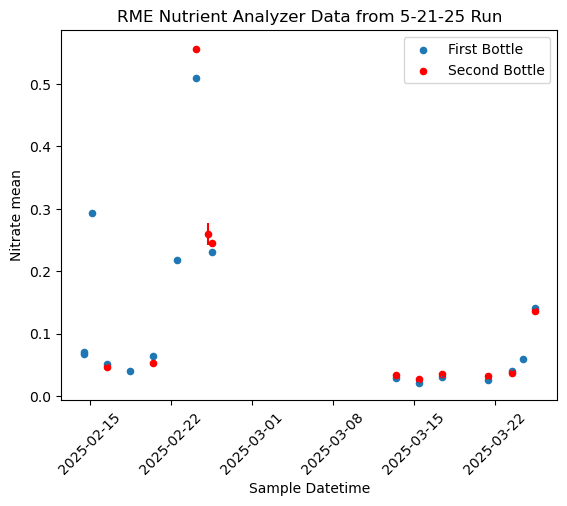

In [10]:
fig, ax=  plt.subplots()
first_rep = result_05212025.result_df['Bottle Replicate']==1

result_05212025.result_df[first_rep].loc['RME'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['RME'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'RME Nutrient Analyzer Data from 5-21-25 Run')

- looks pretty good! good matches betweenn bottles except the 24th
- AA500 variation looks pretty good too, only the 2/25 sample is pretty bad
- these are also samples that i filtered... 

<Axes: title={'center': 'Dobson Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

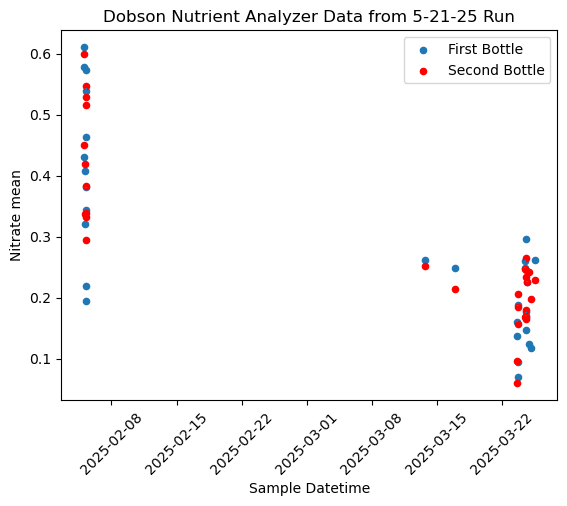

In [16]:
fig, ax=  plt.subplots()
first_rep = result_05212025.result_df['Bottle Replicate']==1

result_05212025.result_df[first_rep].loc['Dobson'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['Dobson'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'Dobson Nutrient Analyzer Data from 5-21-25 Run')

<Axes: title={'center': 'Dobson Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

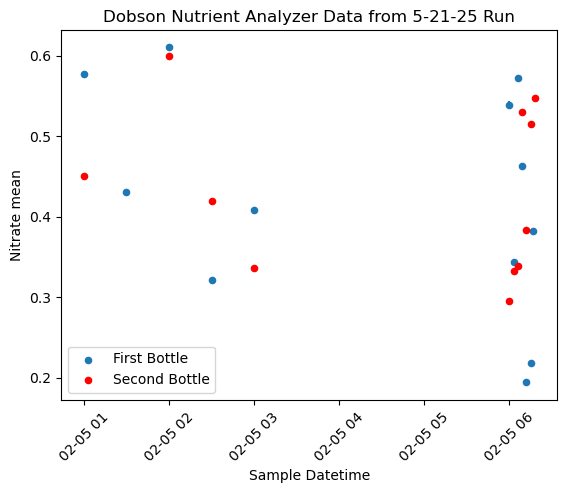

In [14]:
fig, ax=  plt.subplots()
first_rep = result_05212025.result_df['Bottle Replicate']==1

result_05212025.result_df[first_rep].loc['Dobson'].loc[:'2025-02-08'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['Dobson'].loc[:'2025-02-08'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'Dobson Nutrient Analyzer Data from 5-21-25 Run')

<Axes: title={'center': 'Dobson Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

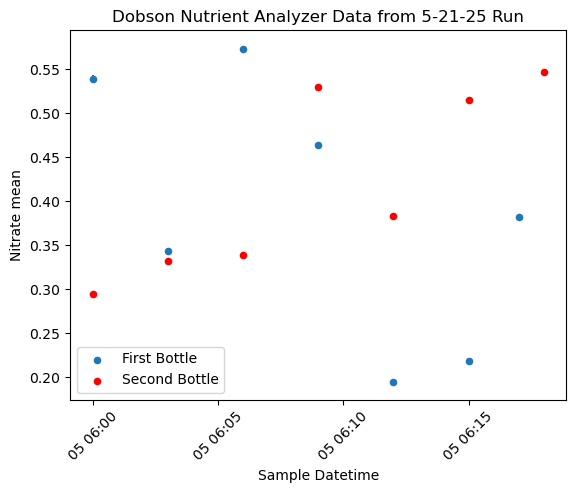

In [15]:
fig, ax=  plt.subplots()
first_rep = result_05212025.result_df['Bottle Replicate']==1

result_05212025.result_df[first_rep].loc['Dobson'].loc['2025-02-05 05:00':'2025-02-08'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['Dobson'].loc['2025-02-05 05:00':'2025-02-08'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'Dobson Nutrient Analyzer Data from 5-21-25 Run')

<Axes: title={'center': 'Dobson Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

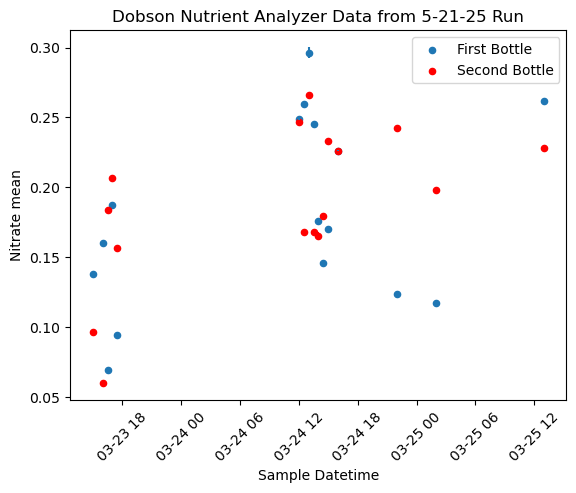

In [17]:
fig, ax=  plt.subplots()
first_rep = result_05212025.result_df['Bottle Replicate']==1

result_05212025.result_df[first_rep].loc['Dobson'].loc['2025-03-22':].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['Dobson'].loc['2025-03-22':].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'Dobson Nutrient Analyzer Data from 5-21-25 Run')

- yikes. Dobson data is straight trash. huge variability between bottle replicates.
- I suspect this has to less to do with it being Dobson or RME and more to do with it being samples I filtered vs samples josh filtered. Or could be that the RME samples were filtered very freshly.

## Plotting with SCAN Data

In [38]:
rme_cleaned = pd.read_csv('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/Reynolds Nitrate Monitoring/SCAN Data/RME/Processed Data/rme_cleaned.csv', index_col='Date/Time', parse_dates=True)
rme_cleaned

,200.0,202.5,205.0,207.5,210.0,212.5,215.0,217.5,220.0,222.5,...,750.0,one_wavelength,one_wavelength_no3,two_wavelength,two_wavelength_no3,second_derivative,second_derivative_no3,two_wavelength_no3_mgl,one_wavelength_no3_mgl,second_derivative_no3_mgl
Date/Time,,,,,,,,,,,,,,,,,,,,,
2025-01-23 18:10:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857158,0.612866,...,NaN,0.857158,3.124335,-0.010212,-1.017683,0.184406,8.668089,-0.014248,0.043741,0.121353
2025-01-23 18:25:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.893012,0.617854,...,NaN,0.893012,3.241218,0.052458,-0.786431,0.174396,8.253469,-0.011010,0.045377,0.115549
2025-01-23 18:40:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.904527,0.614024,...,NaN,0.904527,3.278759,0.061254,-0.753974,0.176402,8.336580,-0.010556,0.045903,0.116712
2025-01-23 18:55:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.918794,0.625615,...,NaN,0.918794,3.325267,0.114938,-0.555880,0.158420,7.591739,-0.007782,0.046554,0.106284
2025-01-23 19:10:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.920580,0.634453,...,NaN,0.920580,3.331091,0.102590,-0.601445,0.178429,8.420534,-0.008420,0.046635,0.117887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-12 10:27:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.332939,2.365764,...,NaN,3.332939,11.195381,3.439639,11.712267,0.478224,20.838029,0.163972,0.156735,0.291732
2025-05-12 10:42:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.319429,2.343151,...,NaN,3.319429,11.151339,3.435118,11.695585,0.458203,20.008756,0.163738,0.156119,0.280123
2025-05-12 10:57:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.356284,2.362283,...,NaN,3.356284,11.271487,3.473997,11.839049,0.462185,20.173703,0.165747,0.157801,0.282432


/Users/beneck/anaconda3/envs/ReynoldsNitrate/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1382: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(data[x].values, data[y].values, linestyle="none", **err_kwds)


<Axes: title={'center': 'RME Nutrient Analyzer Data from 5-21-25 Run'}, xlabel='Sample Datetime', ylabel='Nitrate mean'>

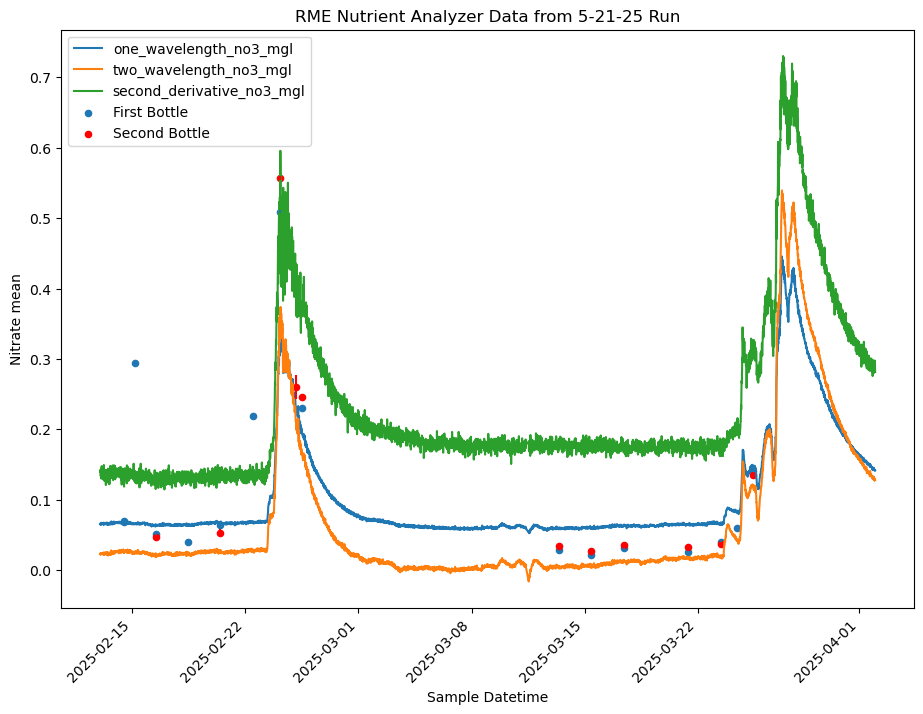

In [43]:
fig, ax= plt.subplots(figsize=(11,8.5))

first_rep = result_05212025.result_df['Bottle Replicate']==1


rme_cleaned.loc['2-13-25':'4-01-25'].plot(y= ['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], ax=ax, rot=45)
result_05212025.result_df[first_rep].loc['RME'].loc['2-13-25':'4-01-25'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45, label = 'First Bottle')
result_05212025.result_df[~first_rep].loc['RME'].loc['2-13-25':'4-01-25'].reset_index().plot(x='Sample Datetime', y='Nitrate mean',ax=ax, yerr= 'Nitrate std',kind='scatter', rot=45,color='r', label = 'Second Bottle', title = 'RME Nutrient Analyzer Data from 5-21-25 Run')


- well cool. there's a couple outliers, on 2/15/25 3:30:00 and another 2-22-25 11:00. but overall theses data catch the general form of the S::CAN data. we can work with it. 

In [44]:
result_05212025.result_df.loc['RME']

,Site Number,Sample Number,Sample Collected,Julian Day Sample Collected,Year Sample Collected,Time Sample Collected,Autosampler Tray Collected,Julian Day Autosampler Tray Collected,Sample Type,Collected By,...,Notes,Nitrate mean,Nitrate std,Phosphate mean,Phosphate std,Ammonium mean,Ammonium std,Nitrate QA,Phosphate QA,Ammonium QA
Sample Datetime,,,,,,,,,,,,,,,,,,,,,
2025-02-14 11:00:00,166.0,1.2,2025-02-14,45.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.067667,0.000577,0.023000,1.732051e-03,0.012000,2.124594e-18,,,
2025-02-14 11:00:00,166.0,1.1,2025-02-14,45.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.069667,0.000577,0.025000,4.358899e-03,0.012000,1.000000e-03,,ISV,
2025-02-15 03:30:00,166.0,7.1,2025-02-15,46.0,2025.0,03:30:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.293667,0.001155,0.042333,2.516611e-03,0.018000,1.000000e-03,,,
2025-02-16 11:00:00,166.0,2.2,2025-02-16,47.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.046667,0.000577,0.021333,2.081666e-03,0.011000,1.000000e-03,,,
2025-02-16 11:00:00,166.0,2.1,2025-02-16,47.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.050667,0.001155,0.024000,4.249187e-18,0.013333,5.773503e-04,,,
2025-02-18 11:00:00,166.0,3.1,2025-02-18,49.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.040333,0.000577,0.022667,5.773503e-04,0.034333,5.773503e-04,,,
2025-02-20 11:00:00,166.0,4.2,2025-02-20,51.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.052667,0.004933,0.020333,5.773503e-04,0.011000,2.124594e-18,,,
2025-02-20 11:00:00,166.0,4.1,2025-02-20,51.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.063667,0.000577,0.042333,3.511885e-03,0.019000,0.000000e+00,,,
2025-02-22 11:00:00,166.0,5.1,2025-02-22,53.0,2025.0,11:00:00,NaN,NaN,Autosampler,Autosampler,...,NaN,0.218333,0.001528,0.031667,2.309401e-03,0.013000,0.000000e+00,,,
